# Hutchinson Trace Estimator

Hongli Zhao, honglizhaobob@uchicago.edu

April 7th, 2022

In [66]:
import numpy as np
import numpy.linalg as la
import scipy
import matplotlib.pyplot as plt
import matplotlib
font = {
        'weight' : 'bold',
        'size'   : 30}
matplotlib.rc('font', **font)

%matplotlib inline
import torch
from torch.autograd.functional import jacobian
from torch import tensor
torch.manual_seed(0)
np.random.seed(0)

We test the following (boring) function:
$$
    g(z) = 
    \begin{bmatrix}
        \sin(z_1) \\
        \sin(z_2) \\
        \vdots\\
        \sin(z_d)
    \end{bmatrix}
$$ 

Then we have:
$$
    J_g = \text{diag}([\cos(z_1),\ldots, \cos(z_d)])
$$

We verify below that indeed $\log\det(A) = \text{tr}(\log(A))$

In [10]:
# highest dimension for testing
d = 64
# create data point
z = torch.rand([1, d], requires_grad=True)
f_z = torch.sin(z)
Df = jacobian(torch.sin, z).squeeze()
I = torch.eye(d)
target = I+Df
exact = torch.log(torch.det(target))
exact2 = torch.trace(torch.log(target))
print(torch.abs(exact - exact2))

tensor(0.)


**Series approximation**: We compute the Hutchinson trace estimator and plot the convergence as a function of series truncation order $n$. For the matrix-vector product, we sample $m=10^3$ vectors.

In [58]:
truncation_ord = np.arange(1, 200)
num_ords = len(truncation_ord)
all_errors = np.zeros([1, num_ords])
estimate = np.zeros([1, num_ords]) # n-th term in the series, cumsum should do it

m = 1000
def sample_v(n, d):
    """ Generate n Radamacher vectors of dimension d. """
    p = 0.5 * torch.ones(n, d)
    return 2*torch.bernoulli(p)-1

n = num_ords
# accumulate matrix powers
w = sample_v(m, d)
v = w.clone()
for j in range(n):
    k = j + 1
    
    trace = 0
    # update running vector w and compute estimator
    for l in range(m):
        tmp_v_l = v[l, :]
        w[l, :] = Df@w[l, :]
        trace += w[l, :]@tmp_v_l
    trace = trace / m
    
    # compute trace at level k
    trace = ((-1)**(k+1))*(trace / k)
    
    # save approximate trace at level n
    estimate[:, j] = trace.item()

In [64]:
hutchinson = np.cumsum(estimate)

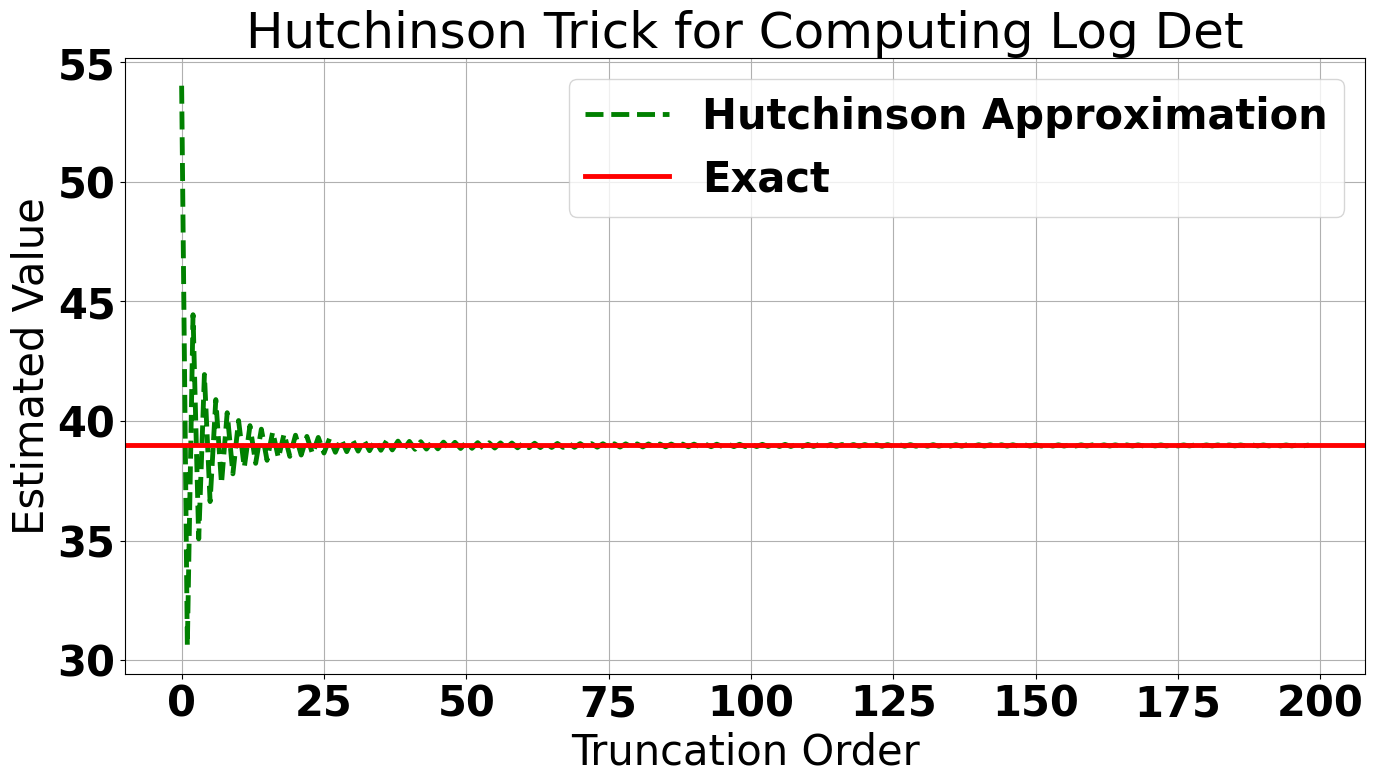

In [71]:
plt.figure(1, figsize=(16, 8))
plt.plot(hutchinson.T, "--", color='green', lw=3.5, label='Hutchinson Approximation');
plt.axhline(exact, color='red', lw=3.5, label='Exact');
plt.legend(); plt.xlabel("Truncation Order"); plt.ylabel("Estimated Value");
plt.title("Hutchinson Trick for Computing Log Det");
plt.grid(True);

Looks alright, let's compute the relative errors.

In [76]:
rel_errors = np.abs(hutchinson - exact.item())/exact.item()

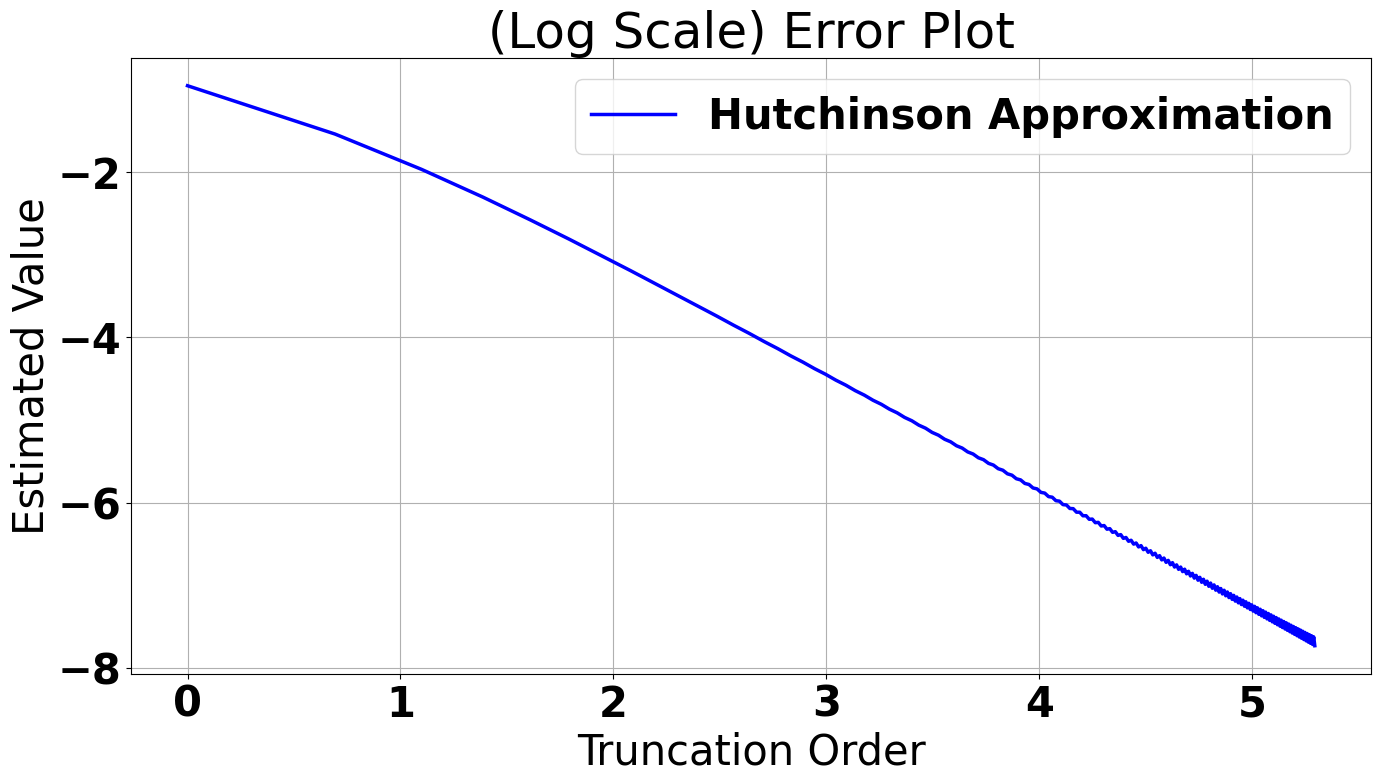

In [80]:
plt.figure(2, figsize=(16, 8))
plt.plot(np.log(np.arange(1, len(rel_errors)+1)), np.log(rel_errors), color='blue', lw=2.5, label='Hutchinson Approximation');
plt.legend(); plt.xlabel("Truncation Order"); plt.ylabel("Estimated Value");
plt.title("(Log Scale) Error Plot");
plt.grid(True);